# Import modules

In [1]:
import numpy as np
import pandas as pd
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.simulation import Simulation
from pipedream_solver.diagnostics import PerformanceTracker, CFLTracker
import matplotlib.pyplot as plt
import seaborn as sns

# Read input data

In [2]:
scenario = 'hillslope_cliff'
input_path = f'../data/{scenario}'
superjunctions = pd.read_csv(f'{input_path}/{scenario}__superjunctions.csv', index_col=0)
superlinks = pd.read_csv(f'{input_path}/{scenario}__superlinks.csv', index_col=0)
Q_in = pd.read_csv(f'{input_path}/{scenario}__Q_j.csv', index_col=0)
Q_Ik = pd.read_csv(f'{input_path}/{scenario}__Q_Ik.csv', index_col=0)

# Instantiate model

In [3]:
# Simulation parameters
dt = 1200
internal_links = 100
num_iter = 200
spinup_steps = 500

# Instantiate model
model = SuperLink(superlinks, superjunctions, 
                  internal_links=internal_links)

# Set bottom slopes at terminal links to zero
model._S_o_uk.fill(0.)
model._S_o_dk.fill(0.)

# Spin up model
model.spinup(n_steps=spinup_steps)
model.volume_tracker.set_init_volume()

# Add run-time performance tracker
performance_tracker = PerformanceTracker(model)
model.bind_callback(performance_tracker, 'performance_tracker')
model.performance_tracker = performance_tracker

# Set parameters for Newton iterations
model.convergence_tracker.max_learning_rate = 1.
model.convergence_tracker.beta = 2.
model.convergence_tracker.xtol = 1e-8

# CFL tracking
cfl_tracker = CFLTracker(model, safety_factor=2., dt_min=60., dt_max=1800.)

# Run simulation

In [4]:
# Create dictionaries to store diagnostic information
iterations_elapsed = {}
convergence_queues = {}
learning_queues = {}
error_queues = {}
decrement_queues = {}
volume_in_system = {}
volume_net_added = {}
step_time_taken = {}

In [5]:
# Create simulation context manager
with Simulation(model, Q_in=Q_in, Q_Ik=Q_Ik) as simulation:
    # While simulation time has not expired...
    while simulation.t <= simulation.t_end:
        dt = cfl_tracker.cfl_timestep()
        # Step model forward in time
        simulation.step(dt=dt, num_iter=num_iter)
        # Record internal depth and flow states
        simulation.record_state()
        simulation.print_progress()
        # Store diagnostic metrics
        iterations_elapsed[simulation.t] = model.iter_elapsed
        convergence_queues[simulation.t] = model.convergence_tracker.convergence_queue
        error_queues[simulation.t] = model.convergence_tracker.error_queue
        decrement_queues[simulation.t] = model.convergence_tracker.decrement_queue
        learning_queues[simulation.t] = model.convergence_tracker.learning_queue
        volume_in_system[simulation.t] = model.volume_tracker.total_volume
        volume_net_added[simulation.t] = model.volume_tracker.cumulative_volume_flux
        step_time_taken[simulation.t] = model.performance_tracker.step_time_elapsed

[==================================================] 100.0% [1.65 s]

# Water surface profile at end

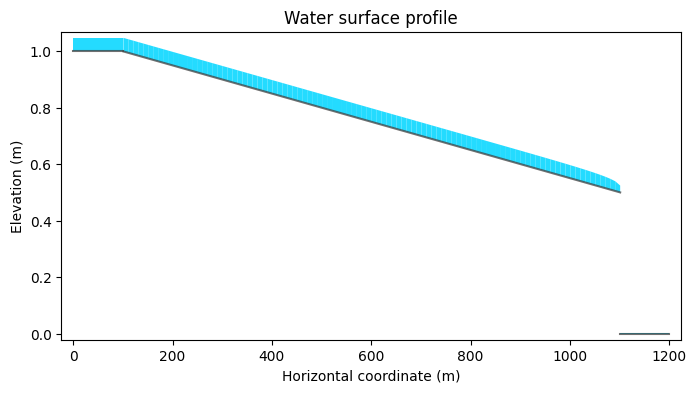

In [6]:
sns.set_palette('cool')
fig, ax = plt.subplots(figsize=(8, 4))
_ = model.plot_profile([0, 1], width=100, ax=ax)
_ = plt.title('Water surface profile')

# Time series of states

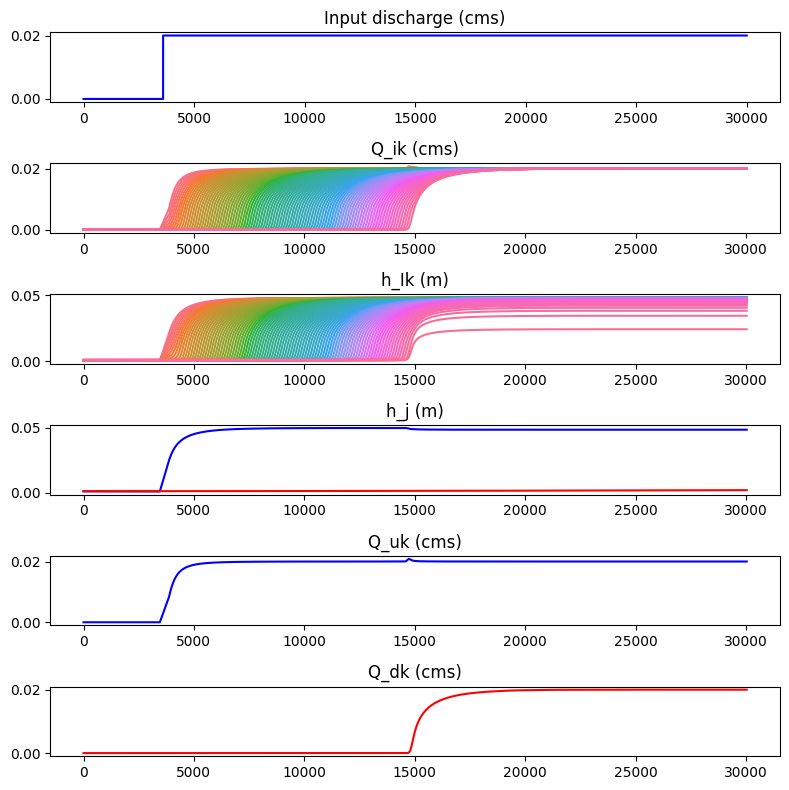

In [7]:
# Instantiate plot
sns.set_palette('husl', internal_links + 1)
fig, ax = plt.subplots(6, figsize=(8, 8))

# Plot results
simulation.Q_in['0'].plot(ax=ax[0], title='Input discharge (cms)', c='b')
simulation.states.Q_ik.plot(ax=ax[1], title='Q_ik (cms)', legend=False)
simulation.states.h_Ik.plot(ax=ax[2], title='h_Ik (m)', legend=False)
(simulation.states.H_j - model._z_inv_j).plot(ax=ax[3], title='h_j (m)', legend=False, color=['b', 'r'])
simulation.states.Q_uk.plot(ax=ax[4], title='Q_uk (cms)', legend=False, c='b')
simulation.states.Q_dk.plot(ax=ax[5], title='Q_dk (cms)', legend=False, c='r')

# Configure plots
plt.tight_layout()


# Mass balance analysis

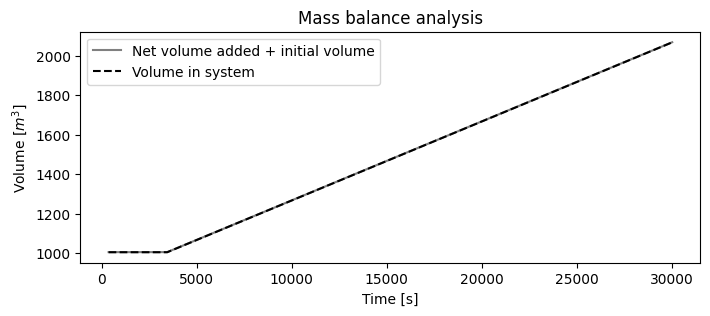

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
(pd.Series(volume_net_added) + model.volume_tracker.init_volume).plot(ax=ax, label='Net volume added + initial volume', c='0.5')
pd.Series(volume_in_system).plot(ax=ax, label='Volume in system', c='k', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Volume [$m^3$]')
plt.title('Mass balance analysis')
_ = plt.legend()

# Convergence analysis

### Step convergence criterion $||x_{new} - x_{old}||_\infty$

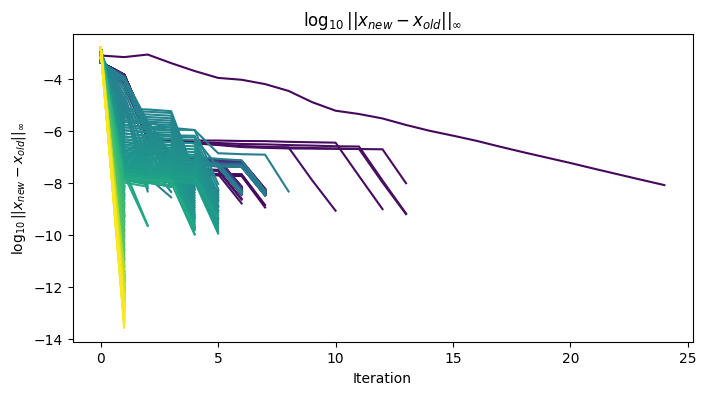

In [9]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in convergence_queues:
    ax.plot(np.log10(np.vstack(convergence_queues[key])).max(axis=1))
_ = plt.title('$\log_{10} ||x_{new} - x_{old}||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||x_{new} - x_{old}||_\infty$')

### Error convergence criterion $||f(x)||_\infty$

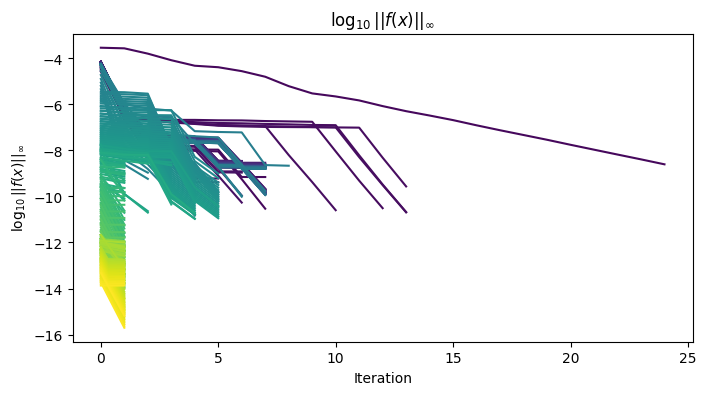

In [10]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in error_queues:
    ax.plot(np.log10(np.array(error_queues[key])))
_ = plt.title('$\log_{10} ||f(x)||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||f(x)||_\infty$')


#### Newton decrement $\nabla f(x)^T \Delta x$

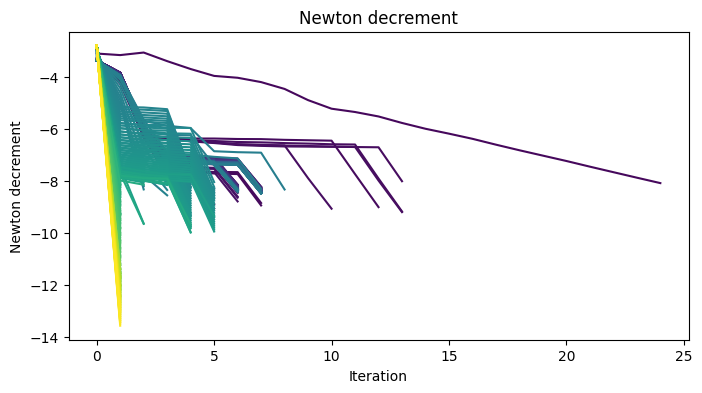

In [11]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in decrement_queues:
    ax.plot(np.log10(np.array(decrement_queues[key])))
_ = plt.title('Newton decrement')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('Newton decrement')


### Newton step size

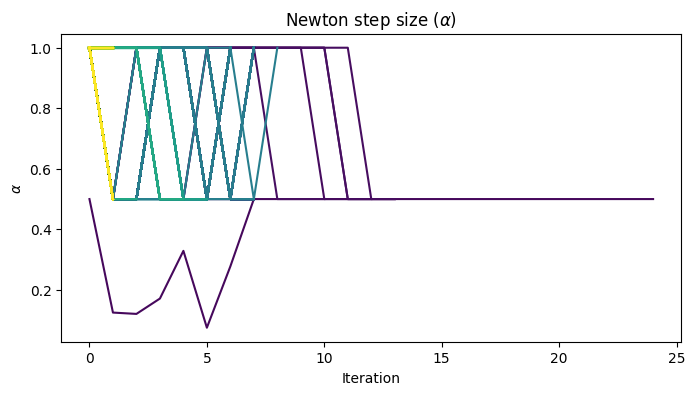

In [12]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in learning_queues:
    ax.plot(np.array(learning_queues[key]))
_ = plt.title('Newton step size ($\\alpha$)')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\\alpha$')


### Number of iterations elapsed

Text(0, 0.5, 'Iterations')

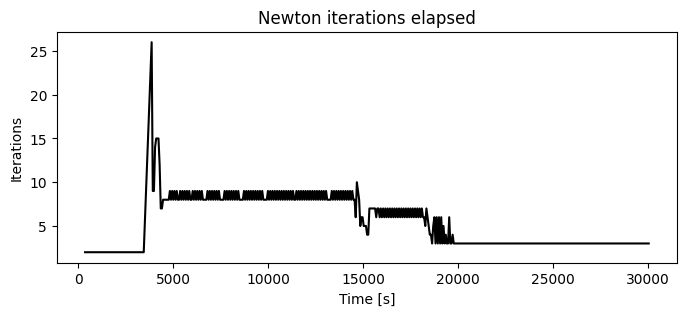

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(iterations_elapsed).plot(ax=ax, c='k')
plt.title('Newton iterations elapsed')
plt.xlabel('Time [s]')
plt.ylabel('Iterations')

### Simulation time elapsed

Text(0, 0.5, 'Clock time elapsed [s]')

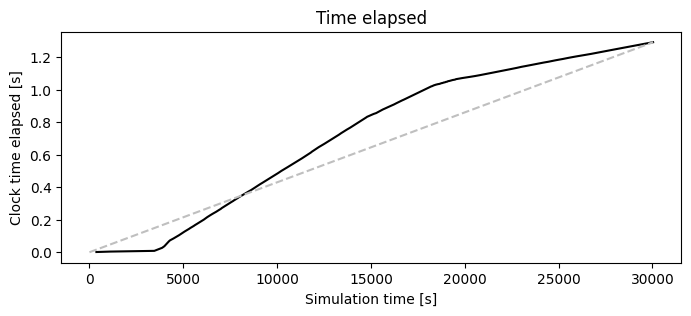

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(step_time_taken).cumsum().plot(ax=ax, c='k')
plt.plot([0, simulation.t], [0, pd.Series(step_time_taken).cumsum().iloc[-1]], c='0.75', linestyle='--')
plt.title('Time elapsed')
plt.xlabel('Simulation time [s]')
plt.ylabel('Clock time elapsed [s]')